# 06 — Precisão, Concisão, Latência e Custo

Este notebook analisa os quatro fatores de avaliação simultaneamente, sempre com **precisão no eixo y**.

---

## Definições

| Coluna | Definição |
|---|---|
| **Precisão** | Média de `avaliacao_final` (escala 0 / 0.5 / 1). Representa a proporção ponderada de respostas corretas ou parcialmente corretas segundo o juiz consolidado. |
| **Concisão** | Média de `concisao_score` (0 ou 1). Proporção de respostas julgadas diretas ao ponto, sem informação não pedida. |
| **Latência** | Média de `latencia_s` — tempo total de resposta em segundos, medido do envio da requisição até o fim do streaming. **Disponível apenas para modelos via API (ferramenta).** Os modelos de chat web (ChatGPT e Claude pela interface) não têm essa instrumentação. |
| **Custo** | Média de `custo_estimado_usd` — custo **por pergunta respondida**, em dólares. Calculado por `input_tokens × preço_input + output_tokens × preço_output` (preço de tabela do provedor), onde os tokens já acumulam **todas as chamadas à ferramenta** feitas para responder aquela pergunta (média de 2,3 chamadas por pergunta). Não é custo por chamada de API — é o custo total que o sistema incorre para entregar uma resposta ao usuário. **Disponível apenas para ferramenta.** Chat web (assinatura fixa) aparece como — na tabela e é omitido dos scatters de custo. |


> **Nota sobre os modelos de chat web** (`ChatGPT (chat web)` e `Claude (chat web)`): responderam as mesmas perguntas mas pela interface de chat público, sem acesso ao edital via RAG. Latência e custo são NaN nesses modelos — nos gráficos aparecem como **quadrado cinza** para distinguir dos círculos coloridos da ferramenta.

In [1]:
import sys
sys.path.insert(0, '.')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Wedge
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from adjustText import adjust_text

from utils import (
    carregar_dados, estilo_padrao,
    ORDEM_MODELOS, CORES_FAMILIA, FAMILIA, MODELO_DISPLAY,
    titulo_acima,
)

estilo_padrao()
df = carregar_dados()

## 1. Tabela mestre — quatro dimensões por modelo

In [2]:
mestre = (
    df.groupby('modelo_display').agg(
        precisao  =('avaliacao_final',           'mean'),
        concisao  =('concisao_score',            'mean'),
        latencia  =('latencia_s',                'mean'),
        custo     =('custo_estimado_usd',         'mean'),
        origem    =('origem_resultado',           'first'),
        familia   =('familia',                   'first'),
    )
    .loc[ORDEM_MODELOS]
    .copy()
)

# Para os scatters de custo: chats entram como 0 (sem custo mensurável por consulta)
mestre['custo_plot'] = mestre['custo'].fillna(0)
mestre['is_chat']    = mestre['origem'] == 'chat_comercial'

# Tabela formatada
fmt = mestre[['precisao','concisao','latencia','custo']].copy()
fmt['precisao'] = (fmt['precisao'] * 100).round(1).astype(str) + '%'
fmt['concisao'] = (fmt['concisao'] * 100).round(1).astype(str) + '%'
fmt['latencia'] = fmt['latencia'].apply(lambda v: f'{v:.1f}s' if pd.notna(v) else '—')
fmt['custo']    = fmt['custo'].apply(lambda v: f'US$ {v:.4f}' if pd.notna(v) else '—')
fmt.columns = ['Precisão', 'Concisão', 'Latência (média)', 'Custo por consulta']
fmt

,Precisão,Concisão,Latência (média),Custo por consulta
modelo_display,,,,
GPT-4o mini,91.0%,88.7%,5.6s,US$ 0.0014
GPT-5.4 mini,90.7%,99.3%,2.9s,US$ 0.0060
GPT-5.4,96.3%,97.3%,5.7s,US$ 0.0236
GPT-5.5,99.7%,97.3%,21.3s,US$ 0.0547
Claude Haiku 4.5,93.7%,53.3%,17.5s,US$ 0.0172
Claude Sonnet 4.6,97.3%,36.0%,12.9s,US$ 0.0538
Claude Opus 4.7,97.7%,48.7%,12.3s,US$ 0.1070
DeepSeek v4 Flash,97.0%,56.0%,8.6s,US$ 0.0020
DeepSeek v4 Pro,96.3%,47.3%,17.9s,US$ 0.0250


## 2. Precisão × Concisão

Quanto mais no quadrante superior-direito, melhor: alta precisão **e** alta concisão.  
Modelos de chat web aparecem como **■ cinza** (sem instrumentação de custo/latência).

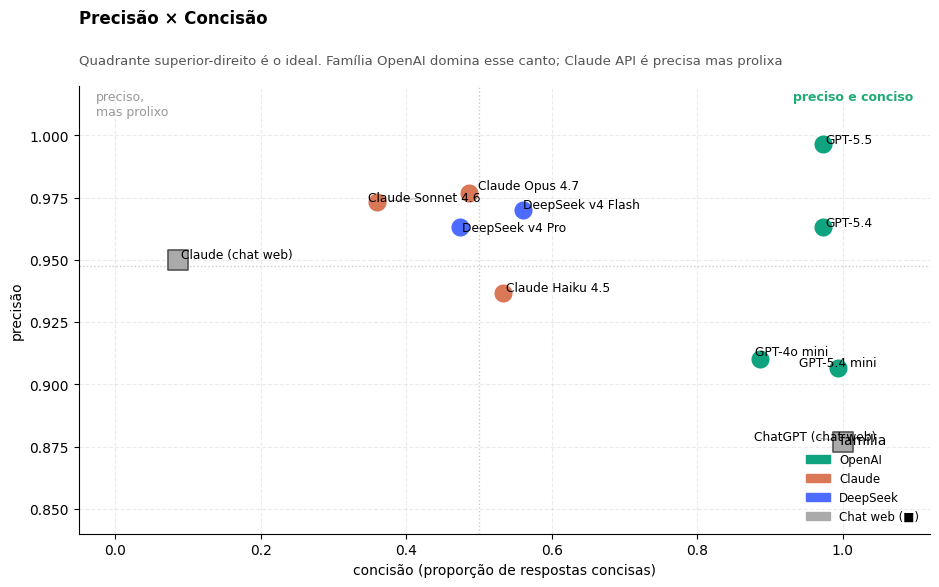

In [3]:
fig, ax = plt.subplots(figsize=(9.5, 6.5))

for m, row in mestre.iterrows():
    cor = CORES_FAMILIA[row['familia']]
    if row['is_chat']:
        ax.scatter(row['concisao'], row['precisao'], s=220,
                   c='#aaa', marker='s', edgecolor='#555', linewidth=1.2, zorder=3)
    else:
        ax.scatter(row['concisao'], row['precisao'], s=220,
                   c=cor, marker='o', edgecolor='white', linewidth=1.8, zorder=3)

texts = [
    ax.text(row['concisao'], row['precisao'], m, fontsize=8.8)
    for m, row in mestre.iterrows()
]
adjust_text(texts, ax=ax,
            arrowprops=dict(arrowstyle='-', color='#aaa', lw=0.6))

# Quadrante
ax.axvline(0.5, ls=':', color='#ccc', lw=1)
ax.axhline(mestre['precisao'].mean(), ls=':', color='#ccc', lw=1)
ax.text(0.98, 0.99, 'preciso e conciso', transform=ax.transAxes,
        ha='right', va='top', fontsize=9, color='#2a7', weight='bold')
ax.text(0.02, 0.99, 'preciso,\nmas prolixo', transform=ax.transAxes,
        ha='left', va='top', fontsize=9, color='#999')

# Legenda de família
handles = [mpatches.Patch(color=c, label=f) for f, c in CORES_FAMILIA.items()]
handles.append(mpatches.Patch(color='#aaa', label='Chat web (■)'))
ax.legend(handles=handles, loc='lower right', title='família', fontsize=8.5)

ax.set_xlabel('concisão (proporção de respostas concisas)')
ax.set_ylabel('precisão')
ax.set_xlim(-0.05, 1.12)
ax.set_ylim(0.84, 1.02)
titulo_acima(ax,
    'Precisão × Concisão',
    'Quadrante superior-direito é o ideal. Família OpenAI domina esse canto; Claude API é precisa mas prolixa')
plt.tight_layout(rect=[0,0,1,0.93])
plt.show()

## 3. Precisão × Latência

Quanto mais no quadrante superior-esquerdo, melhor: alta precisão **e** resposta rápida.  
Modelos de chat web não têm latência medida e aparecem como **■ cinza** fora dos eixos principais.

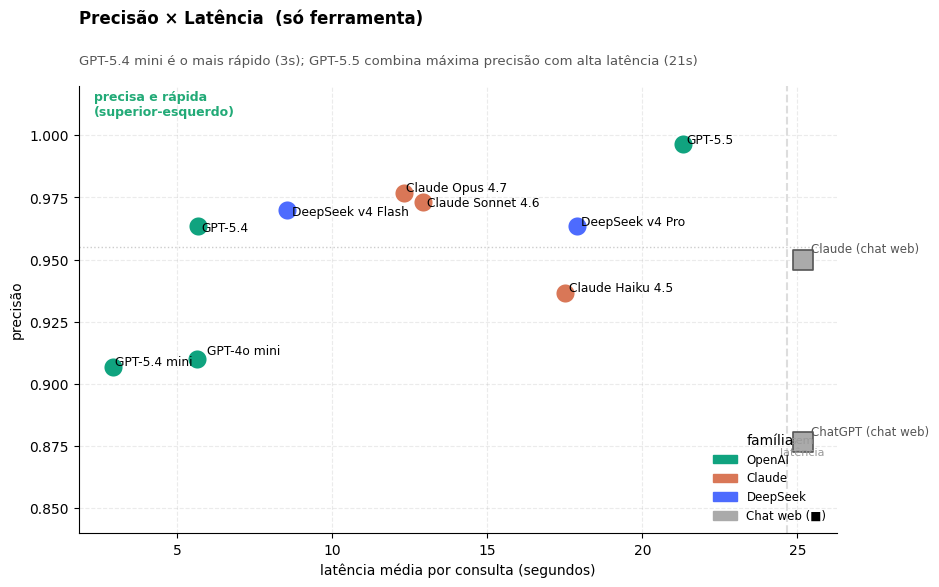

In [4]:
fig, ax = plt.subplots(figsize=(9.5, 6.5))

fer = mestre[~mestre['is_chat']]
chat = mestre[mestre['is_chat']]

for m, row in fer.iterrows():
    cor = CORES_FAMILIA[row['familia']]
    ax.scatter(row['latencia'], row['precisao'], s=220,
               c=cor, marker='o', edgecolor='white', linewidth=1.8, zorder=3)

# Chats: coluna cinza à direita do plot (sem valor x real)
x_chat = fer['latencia'].max() * 1.18
for m, row in chat.iterrows():
    ax.scatter(x_chat, row['precisao'], s=220,
               c='#aaa', marker='s', edgecolor='#555', linewidth=1.2, zorder=3)
    ax.annotate(m, (x_chat, row['precisao']), xytext=(6, 5),
                textcoords='offset points', fontsize=8.5, color='#555')

# Linha separadora
ax.axvline(x_chat * 0.98, color='#ddd', lw=1.5, ls='--')
ax.text(x_chat, ax.get_ylim()[0] if ax.get_ylim()[0] > 0 else 0.845,
        'sem\nlatência', ha='center', fontsize=8, color='#999', va='bottom')

texts = [
    ax.text(row['latencia'], row['precisao'], m, fontsize=8.8)
    for m, row in fer.iterrows()
]
adjust_text(texts, ax=ax,
            arrowprops=dict(arrowstyle='-', color='#aaa', lw=0.6))

ax.axhline(fer['precisao'].mean(), ls=':', color='#ccc', lw=1)
ax.text(0.02, 0.99, 'precisa e rápida\n(superior-esquerdo)', transform=ax.transAxes,
        ha='left', va='top', fontsize=9, color='#2a7', weight='bold')

handles = [mpatches.Patch(color=c, label=f) for f, c in CORES_FAMILIA.items()]
handles.append(mpatches.Patch(color='#aaa', label='Chat web (■)'))
ax.legend(handles=handles, loc='lower right', title='família', fontsize=8.5)

ax.set_xlabel('latência média por consulta (segundos)')
ax.set_ylabel('precisão')
ax.set_ylim(0.84, 1.02)
titulo_acima(ax,
    'Precisão × Latência  (só ferramenta)',
    'GPT-5.4 mini é o mais rápido (3s); GPT-5.5 combina máxima precisão com alta latência (21s)')
plt.tight_layout(rect=[0,0,1,0.93])
plt.show()

## 4. Precisão × Custo

Quanto mais no quadrante superior-esquerdo, melhor: alta precisão **e** custo baixo.  
Eixo x em escala logarítmica (variação de 75× entre o mais barato e o mais caro).  
Modelos de chat web entram em custo = 0 (sem custo mensurável por consulta individual).

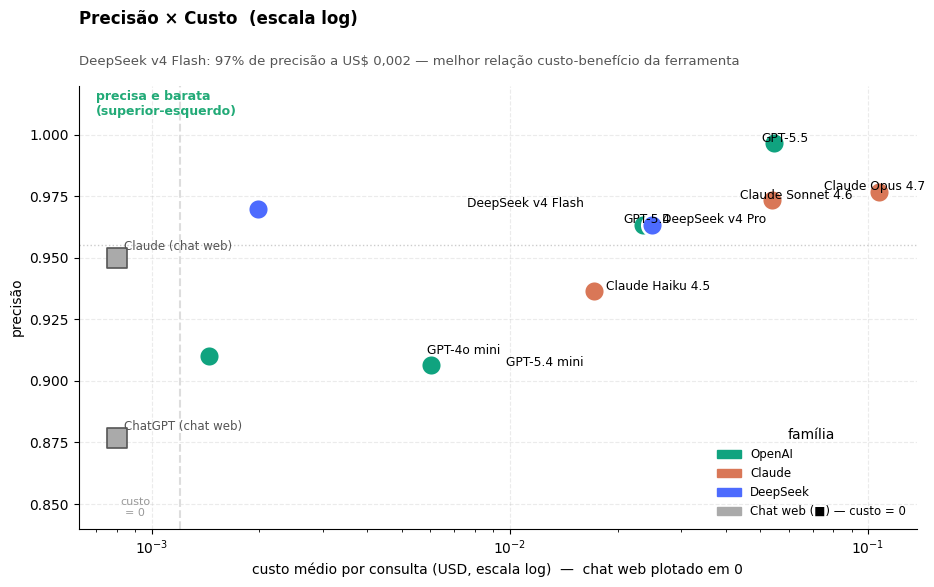

In [5]:
fig, ax = plt.subplots(figsize=(9.5, 6.5))

for m, row in mestre.iterrows():
    cor = CORES_FAMILIA[row['familia']]
    if row['is_chat']:
        # Custo zero: posicionar à esquerda em x simbólico fora da escala log
        ax.scatter(0.0008, row['precisao'], s=220,
                   c='#aaa', marker='s', edgecolor='#555', linewidth=1.2, zorder=3)
        ax.annotate(m, (0.0008, row['precisao']), xytext=(5, 6),
                    textcoords='offset points', fontsize=8.5, color='#555')
    else:
        ax.scatter(row['custo_plot'], row['precisao'], s=220,
                   c=cor, marker='o', edgecolor='white', linewidth=1.8, zorder=3)

texts = [
    ax.text(row['custo_plot'], row['precisao'], m, fontsize=8.8)
    for m, row in mestre[~mestre['is_chat']].iterrows()
]
adjust_text(texts, ax=ax,
            arrowprops=dict(arrowstyle='-', color='#aaa', lw=0.6))

ax.set_xscale('log')
ax.axvline(0.0012, color='#ddd', lw=1.5, ls='--')
ax.text(0.0009, 0.845, 'custo\n= 0', ha='center', fontsize=8, color='#999')

ax.axhline(mestre[~mestre['is_chat']]['precisao'].mean(), ls=':', color='#ccc', lw=1)
ax.text(0.02, 0.99, 'precisa e barata\n(superior-esquerdo)', transform=ax.transAxes,
        ha='left', va='top', fontsize=9, color='#2a7', weight='bold')

handles = [mpatches.Patch(color=c, label=f) for f, c in CORES_FAMILIA.items()]
handles.append(mpatches.Patch(color='#aaa', label='Chat web (■) — custo = 0'))
ax.legend(handles=handles, loc='lower right', title='família', fontsize=8.5)

ax.set_xlabel('custo médio por consulta (USD, escala log)  —  chat web plotado em 0')
ax.set_ylabel('precisão')
ax.set_ylim(0.84, 1.02)
titulo_acima(ax,
    'Precisão × Custo  (escala log)',
    'DeepSeek v4 Flash: 97% de precisão a US$ 0,002 — melhor relação custo-benefício da ferramenta')
plt.tight_layout(rect=[0,0,1,0.93])
plt.show()

## 5. As quatro dimensões num único gráfico — bolinha dividida

Cada modelo é uma bolinha cortada ao meio:

- **Eixo x** → concisão  
- **Eixo y** → precisão  
- **Metade esquerda da bolinha** → latência (azul claro = rápido, azul escuro = lento; cinza = sem dado)  
- **Metade direita da bolinha** → custo (verde claro = barato, vermelho = caro; cinza = sem dado)  
- **Forma** → círculo = ferramenta (API); quadrado = chat web  

> O objetivo não é substituir os três scatters anteriores — é dar uma visão simultânea que mostra quem domina **todas** as dimensões de uma vez.

Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


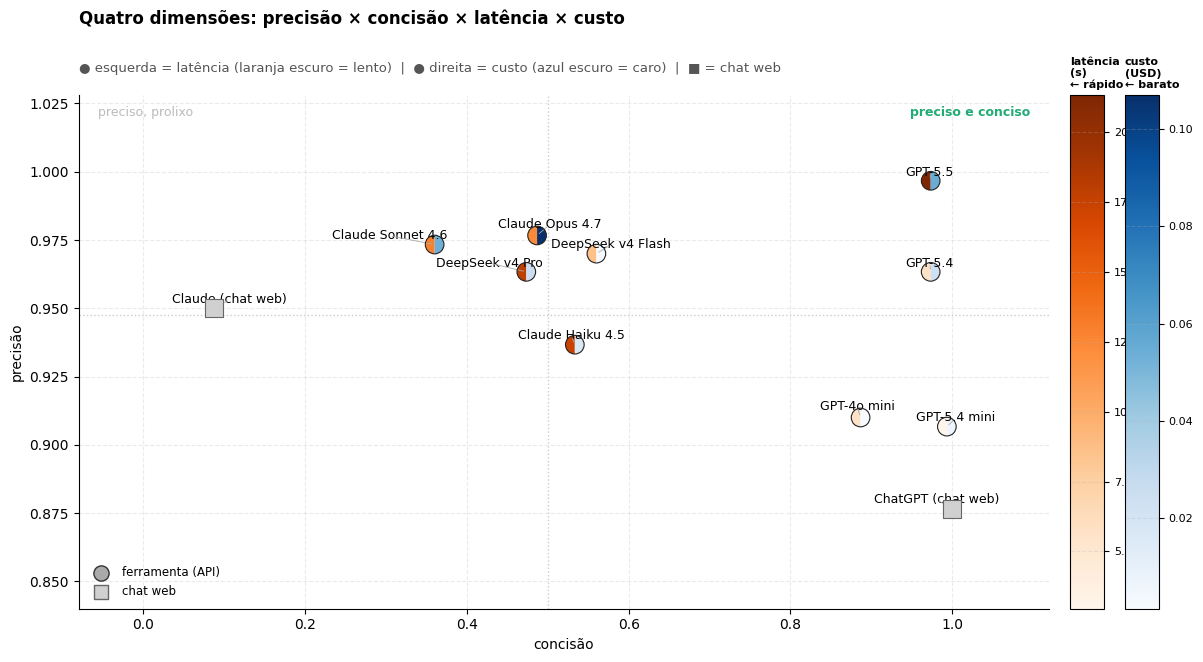

In [6]:
from matplotlib.path import Path
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

fer = mestre[~mestre['is_chat']]
norm_lat   = Normalize(vmin=fer['latencia'].min(), vmax=fer['latencia'].max())
norm_custo = Normalize(vmin=fer['custo'].min(),    vmax=fer['custo'].max())
cmap_lat   = plt.cm.Oranges  # claro = rápido, escuro = lento
cmap_custo = plt.cm.Blues    # claro = barato, escuro = caro

def make_half(side='left', n=100):
    theta = np.linspace(np.pi/2, 3*np.pi/2, n) if side == 'left' \
            else np.linspace(-np.pi/2, np.pi/2, n)
    verts = np.vstack([[0,0], np.c_[np.cos(theta), np.sin(theta)], [0,0]])
    codes = [Path.MOVETO]+[Path.LINETO]*(len(verts)-2)+[Path.CLOSEPOLY]
    return Path(verts, codes)

mk_l, mk_r = make_half('left'), make_half('right')

fig = plt.figure(figsize=(12, 6.5))
gs = fig.add_gridspec(1, 3, width_ratios=[10, 0.35, 0.35],
                      wspace=0.06, left=0.07, right=0.97, top=0.88, bottom=0.09)
ax    = fig.add_subplot(gs[0])
ax_cl = fig.add_subplot(gs[1])
ax_cc = fig.add_subplot(gs[2])

for m, row in mestre.iterrows():
    cx, cy = row['concisao'], row['precisao']
    if row['is_chat']:
        ax.scatter(cx, cy, s=180, marker='s',
                   c='#d0d0d0', edgecolors='#666', linewidths=0.8, zorder=4)
    else:
        cl = cmap_lat(norm_lat(row['latencia']))
        cc = cmap_custo(norm_custo(row['custo']))
        ax.scatter(cx, cy, s=180, marker=mk_l, c=[cl], edgecolors='none', zorder=3)
        ax.scatter(cx, cy, s=180, marker=mk_r, c=[cc], edgecolors='none', zorder=3)
        ax.scatter(cx, cy, s=180, marker='o',  facecolor='none',
                   edgecolors='#222', linewidths=0.8, zorder=5)

texts = [ax.text(row['concisao'], row['precisao'], m, fontsize=9, ha='center', va='bottom')
         for m, row in mestre.iterrows()]
adjust_text(texts,
            x=mestre['concisao'].values,
            y=mestre['precisao'].values,
            ax=ax,
            arrowprops=dict(arrowstyle='-', color='#aaa', lw=0.6),
            expand=(1.4, 1.8),
            force_points=(2.0, 2.5),
            force_text=(0.5, 0.8))

ax.axvline(0.5, ls=':', color='#ccc', lw=1)
ax.axhline(mestre['precisao'].mean(), ls=':', color='#ccc', lw=1)
ax.text(0.98, 0.98, 'preciso e conciso', transform=ax.transAxes,
        ha='right', va='top', fontsize=9, color='#2a7', weight='bold')
ax.text(0.02, 0.98, 'preciso, prolixo', transform=ax.transAxes,
        ha='left', va='top', fontsize=9, color='#bbb')
ax.set_xlabel('concisão')
ax.set_ylabel('precisão')
ax.set_xlim(-0.08, 1.12)
ax.set_ylim(0.840, 1.028)

h_api  = ax.scatter([], [], s=120, marker='o', c='#aaa', edgecolors='#333',
                    label='ferramenta (API)')
h_chat = ax.scatter([], [], s=100, marker='s', c='#d0d0d0', edgecolors='#666',
                    label='chat web')
ax.legend(handles=[h_api, h_chat], loc='lower left', fontsize=8.5, frameon=False)

sm_l = ScalarMappable(norm=norm_lat,   cmap=cmap_lat);   sm_l.set_array([])
sm_c = ScalarMappable(norm=norm_custo, cmap=cmap_custo); sm_c.set_array([])
fig.colorbar(sm_l, cax=ax_cl)
ax_cl.set_title('latência\n(s)\n← rápido', fontsize=8, pad=5)
ax_cl.tick_params(labelsize=8)
fig.colorbar(sm_c, cax=ax_cc)
ax_cc.set_title('custo\n(USD)\n← barato', fontsize=8, pad=5)
ax_cc.tick_params(labelsize=8)
ax_cc.yaxis.set_ticks_position('right')

titulo_acima(ax,
    'Quatro dimensões: precisão × concisão × latência × custo',
    '● esquerda = latência (laranja escuro = lento)  |  ● direita = custo (azul escuro = caro)  |  ■ = chat web')
plt.show()

**Como ler o gráfico de bolinhas divididas:**

Um modelo ideal ficaria no **canto superior-direito** (preciso e conciso), com a **metade esquerda azul claro** (rápido) e a **metade direita verde** (barato).

- `GPT-5.5` está no canto superior-direito mas com metade esquerda azul escuro (lento, 21s) e direita amarela (custo médio, US$ 0,055).
- `DeepSeek v4 Flash` tem metade direita verde intenso (US$ 0,002 — o mais barato), mas está no centro-esquerdo do eixo x (concisão moderada).
- `GPT-5.4 mini` aparece bem no canto direito com ambas as metades em tons claros — o modelo mais equilibrado nas quatro dimensões.
- Os **■ cinzas** (chat web) não têm cor nas metades porque latência e custo por consulta não são mensuráveis nesses modelos.